# EDA & The Graph

--- Class Distribution ---
Legitimate (0): 17014 (95.2%)
Fraudulent (1): 866 (4.8%)


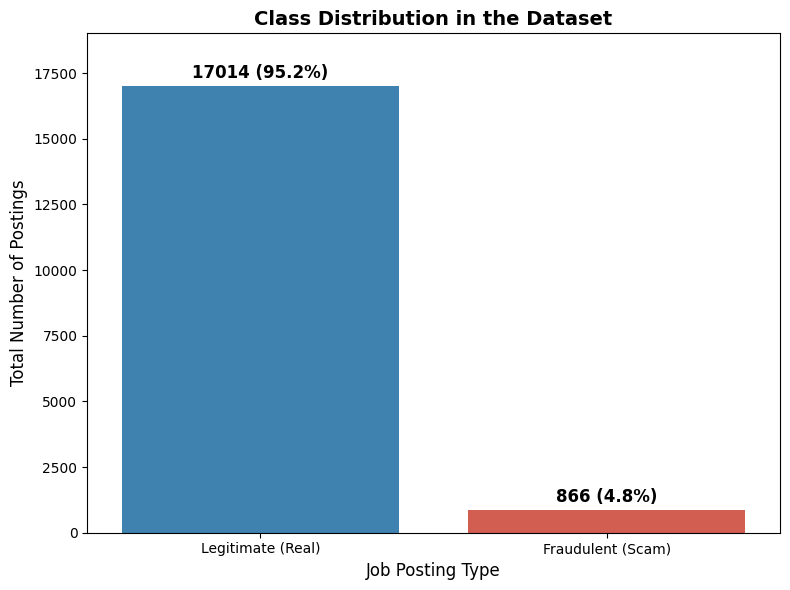

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset (Update the path to match your PC)
file_path = "fake_job_postings.csv"
df = pd.read_csv(file_path)

# 2. Calculate the class imbalance
class_counts = df['fraudulent'].value_counts()
class_percentages = df['fraudulent'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(f"Legitimate (0): {class_counts[0]} ({class_percentages[0]:.1f}%)")
print(f"Fraudulent (1): {class_counts[1]} ({class_percentages[1]:.1f}%)")

# 3. Create the Visualization
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=['Legitimate (Real)', 'Fraudulent (Scam)'], 
                 y=[class_counts[0], class_counts[1]], 
                 palette=['#2E86C1', '#E74C3C'])

plt.title('Class Distribution in the Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Total Number of Postings', fontsize=12)
plt.xlabel('Job Posting Type', fontsize=12)

# Add text labels on top of the bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = class_percentages.iloc[i]
    ax.text(p.get_x() + p.get_width()/2., height + 300,
            f'{int(height)} ({percentage:.1f}%)',
            ha="center", fontsize=12, fontweight='bold')

plt.ylim(0, max(class_counts) + 2000)
plt.tight_layout()
plt.show()

# The Machine Learning Pipeline
1. imports
2. load and clean data
3. TF-IDF vectorization
4. train/test split
5. Naive Bayes baseline
6. Random Forest training and tuning
7. save model and vectorizer
8. Random Forest evaluation
9. feature importance plot
10. false negative analysis

In [2]:
# 1. imports
import pandas as pd
import re
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [3]:
#2. load and clean data
df = pd.read_csv(file_path)
df = df.dropna(subset=['description', 'fraudulent'])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_text'] = df['description'].apply(clean_text)

In [4]:
# 3. TF-IDF vectorization
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['fraudulent']

In [5]:
# 4.Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026,
    stratify=y
)

In [6]:
#5. Train and evaluate Naive Bayes baseline
print("Training Naive Bayes...")

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("\n--- Naive Bayes Results ---")
print(classification_report(y_test, nb_pred))

Training Naive Bayes...

--- Naive Bayes Results ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3403
           1       0.98      0.28      0.43       173

    accuracy                           0.96      3576
   macro avg       0.97      0.64      0.71      3576
weighted avg       0.97      0.96      0.96      3576



In [7]:
# 6. Train and tune Random Forest
print("Tuning & Training Random Forest...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=2026
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

rf_model = grid_search.best_estimator_

print(f"\n>> Best parameters found: {grid_search.best_params_}")

Tuning & Training Random Forest...

>> Best parameters found: {'max_depth': None, 'n_estimators': 200}


In [8]:
#7. save the model and vectorizer for later use
joblib.dump(rf_model, "fraud_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [9]:
# 8. evaluate random forest on the full test set
print("\n--- Random Forest Results ---")

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.93      0.61      0.73       173

    accuracy                           0.98      3576
   macro avg       0.95      0.80      0.86      3576
weighted avg       0.98      0.98      0.98      3576

[[3395    8]
 [  68  105]]



--- Top 10 Most Important Features ---
      Word  Importance
      team    0.014960
   growing    0.009029
    skills    0.008963
      work    0.007795
      time    0.007506
     youll    0.007236
       web    0.007071
   looking    0.006775
     based    0.006549
data entry    0.006397


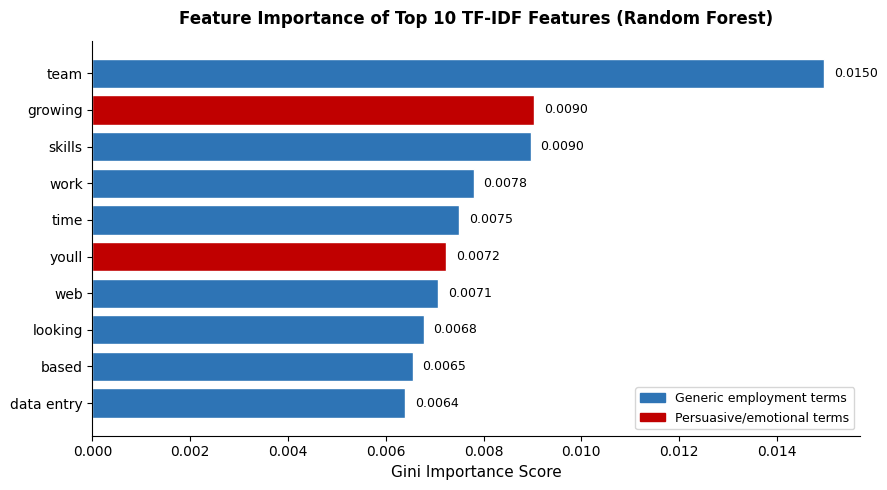

In [10]:
#9. feature importance analysis
importances = rf_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Word': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

print("\n--- Top 10 Most Important Features ---")
print(feature_importance_df[['Word', 'Importance']].to_string(index=False))

# Feature importance chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

words = feature_importance_df['Word'].tolist()
importance = feature_importance_df['Importance'].tolist()

persuasive = ['love', 'youll', 'growing']
colors = ['#C00000' if w in persuasive else '#2E74B5' for w in words]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(words[::-1], importance[::-1], color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, importance[::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Gini Importance Score', fontsize=11)
ax.set_title('Feature Importance of Top 10 TF-IDF Features (Random Forest)',
             fontsize=12, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

blue_patch = mpatches.Patch(color='#2E74B5', label='Generic employment terms')
red_patch  = mpatches.Patch(color='#C00000', label='Persuasive/emotional terms')
ax.legend(handles=[blue_patch, red_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig("_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
#10. General false negative analysis
print("\n--- Investigating Missed Scams (False Negatives) ---")

results_df = pd.DataFrame({
    'text': df.loc[y_test.index, 'description'],
    'actual': y_test,
    'predicted': y_pred
})

false_negatives = results_df[
    (results_df['actual'] == 1) &
    (results_df['predicted'] == 0)
]

print(f"Total missed scams: {len(false_negatives)}")

for index, row in false_negatives.head(3).iterrows():
    print(f"TEXT: {str(row['text'])[:200]}...")
    print("-" * 60)


--- Investigating Missed Scams (False Negatives) ---
Total missed scams: 68
TEXT: Apply using below link#URL_56ff6e6f6d7ee1c89626f7ad9300bd878f5177d001486dec21bbe771072fd7a2#Provides direct patient care, as part of a perioperative (operating room) team, assisting the operating surg...
------------------------------------------------------------
TEXT: Software Engineer | Forecasting + Optimization | San Mateo, CALooking for a smart engineers to work on our next-generation data mining and forecasting platform. The role involves working with business...
------------------------------------------------------------
TEXT: Welcome to one of the toughest and most fulfilling ways to help people, including yourself. We offer the latest tools, most intensive training program in the industry and nearly limitless opportunitie...
------------------------------------------------------------


# Healthcare-Specific EMSCAD Evaluation
1. Seeking healthcare filter list
2. seed healthcare words
3. most common healthcare words
4. bigrams
5. final healthcare keyword list
6. healthcare_test_df
7. healthcare test-only classification report

In [12]:
#1. Seeking healthcare filter list
df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("") + " " +
    df["department"].fillna("")
)

In [13]:
# 2. Define your seed words related to healthcare - Trial and error to find the best set of words
seed_health_words = [
    "nurse",
    "nursing",
    "hospital",
    "clinic",
    "medical",
    "healthcare"
]
seed_pattern = "|".join(seed_health_words)

df_health_seed = df[
    df["combined_text"].str.lower().str.contains(seed_pattern, na=False)
].copy()

print("Seed healthcare posts found:", len(df_health_seed))
print(df_health_seed["fraudulent"].value_counts())

Seed healthcare posts found: 1412
fraudulent
0    1300
1     112
Name: count, dtype: int64


Healthcare-related EMSCAD posts: 1412
Legitimate: 1300
Fraudulent: 112
≈ 7.9% fraudulent

In [14]:
#3. most common healthcare words
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer_words = CountVectorizer(
    stop_words="english",
    max_features=30,
    ngram_range=(1, 1)
)

word_matrix = vectorizer_words.fit_transform(df_health_seed["combined_text"])

word_counts = word_matrix.sum(axis=0).A1

healthcare_word_freq = pd.DataFrame({
    "word": vectorizer_words.get_feature_names_out(),
    "count": word_counts
}).sort_values(by="count", ascending=False)

healthcare_word_freq
print(healthcare_word_freq.to_string(index=False))


       word  count
 experience   2720
       work   2363
       team   1842
       care   1651
     skills   1601
        amp   1312
    service   1267
    ability   1262
    company   1221
   customer   1206
     health   1202
    medical   1201
 management   1194
       time   1066
   required   1056
   business   1013
   services   1010
        new    995
      years    967
        job    926
      sales    907
    provide    902
 healthcare    889
   position    862
    patient    854
    working    854
  including    824
development    810
  knowledge    809
environment    767


top words are not all healthcare-specific. Many are general job words: experience, work, team, skills, company, customer, ability, service

In [15]:
# 4. Extract common healthcare bigrams
vectorizer_bigrams = CountVectorizer(
    stop_words="english",
    max_features=30,
    ngram_range=(2, 2)
)

bigram_matrix = vectorizer_bigrams.fit_transform(df_health_seed["combined_text"])

bigram_counts = bigram_matrix.sum(axis=0).A1

healthcare_bigram_freq = pd.DataFrame({
    "bigram": vectorizer_bigrams.get_feature_names_out(),
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

healthcare_bigram_freq


,bigram,count
4,customer service,539
3,communication skills,329
29,years experience,262
13,home health,208
20,policies procedures,205
26,team members,199
0,ability work,180
10,fast paced,172
11,health care,160
9,experience working,157


In [16]:
print(healthcare_word_freq.to_string(index=False))

       word  count
 experience   2720
       work   2363
       team   1842
       care   1651
     skills   1601
        amp   1312
    service   1267
    ability   1262
    company   1221
   customer   1206
     health   1202
    medical   1201
 management   1194
       time   1066
   required   1056
   business   1013
   services   1010
        new    995
      years    967
        job    926
      sales    907
    provide    902
 healthcare    889
   position    862
    patient    854
    working    854
  including    824
development    810
  knowledge    809
environment    767


In [17]:
print(healthcare_bigram_freq.to_string(index=False))

              bigram  count
    customer service    539
communication skills    329
    years experience    262
         home health    208
 policies procedures    205
        team members    199
        ability work    180
          fast paced    172
         health care    160
  experience working    157
      skills ability    156
      school diploma    154
        patient care    154
        healthy spot    150
     bachelor degree    149
     problem solving    147
      driver license    146
      service skills    136
        social media    128
 experience required    128
       minimum years    126
    work environment    124
     ideal candidate    122
       mental health    121
           join team    120
      driving record    113
     duties assigned    112
business development    112
          multi task    110
      written verbal    109


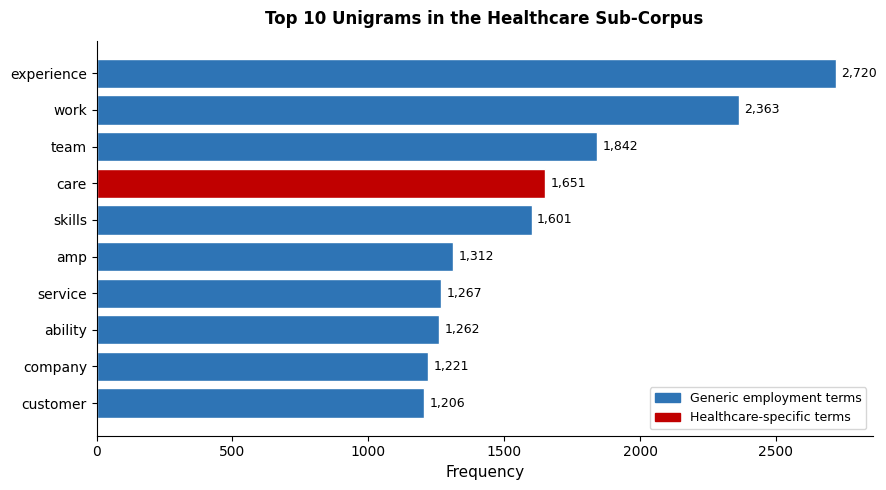

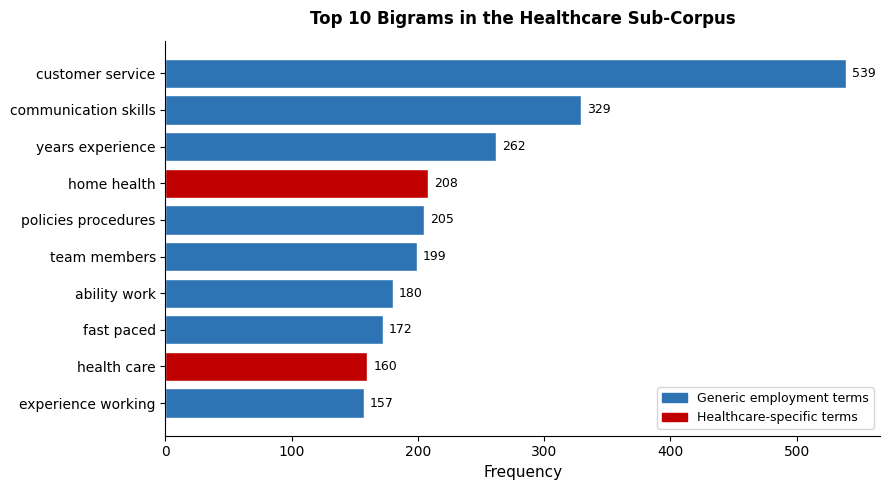

In [18]:
#  Top 10 Unigrams chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

top_unigrams = healthcare_word_freq.head(10)
words_u = top_unigrams['word'].tolist()
counts_u = top_unigrams['count'].tolist()

healthcare_words = ['care', 'health', 'medical']
colors_u = ['#C00000' if w in healthcare_words else '#2E74B5' for w in words_u]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(words_u[::-1], counts_u[::-1], color=colors_u[::-1], edgecolor='white')

for i, (bar, val) in enumerate(zip(ax.patches, counts_u[::-1])):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top 10 Unigrams in the Healthcare Sub-Corpus',
             fontsize=12, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

blue_patch = mpatches.Patch(color='#2E74B5', label='Generic employment terms')
red_patch = mpatches.Patch(color='#C00000', label='Healthcare-specific terms')
ax.legend(handles=[blue_patch, red_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig("fig2_unigrams.png", dpi=150, bbox_inches='tight')
plt.show()

# Top 10 Bigrams chart
top_bigrams = healthcare_bigram_freq.head(10)
words_b = top_bigrams['bigram'].tolist()
counts_b = top_bigrams['count'].tolist()

healthcare_bigrams = ['home health', 'health care', 'patient care']
colors_b = ['#C00000' if w in healthcare_bigrams else '#2E74B5' for w in words_b]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(words_b[::-1], counts_b[::-1], color=colors_b[::-1], edgecolor='white')

for i, (bar, val) in enumerate(zip(ax.patches, counts_b[::-1])):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top 10 Bigrams in the Healthcare Sub-Corpus',
             fontsize=12, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

blue_patch = mpatches.Patch(color='#2E74B5', label='Generic employment terms')
red_patch = mpatches.Patch(color='#C00000', label='Healthcare-specific terms')
ax.legend(handles=[blue_patch, red_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig("fig3_bigrams.png", dpi=150, bbox_inches='tight')
plt.show()

### it shows that the bigram table are more useful.
Use a mix of:
- Data-discovered healthcare words: care, health, medical, healthcare
- Data-discovered healthcare bigrams: home health, health care, patient care
- Research-domain terms: nurse, nursing, hospital, clinic, patient, caregiver

In [19]:
# 5. final healthcare keyword list
health_keywords = [
    "medical",
    "healthcare",
    "nurse",
    "nursing",
    "hospital",
    "clinic",
    "patient",
    "caregiver",
    "home health",
    "health care",
    "patient care"
]

pattern = r"\b(" + "|".join([re.escape(word) for word in health_keywords]) + r")\b"

df_healthcare = df[
    df["combined_text"].str.lower().str.contains(pattern, na=False)
].copy()

print("Healthcare-related EMSCAD posts:", len(df_healthcare))
print(df_healthcare["fraudulent"].value_counts())

Healthcare-related EMSCAD posts: 1404
fraudulent
0    1298
1     106
Name: count, dtype: int64


To define the healthcare-related EMSCAD subset, an initial seed search was conducted using domain terms such as “nurse,” “hospital,” “clinic,” “medical,” and “healthcare.” The resulting subset contained 1,412 postings, including 112 fraudulent cases. Frequency analysis was then applied to the subset using unigram and bigram counts. The most relevant healthcare-specific terms included “care,” “health,” “medical,” “healthcare,” and the bigrams “home health,” “health care,” and “patient care.” These data-informed terms were combined with domain-specific healthcare recruitment terms to construct the final healthcare filter.

In [20]:
df_healthcare.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,clean_text,combined_text
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,job title itemization review managerlocation f...,Bill Review Manager JOB TITLE: Itemization Rev...
10,11,ASP.net Developer Job opportunity at United St...,"US, NJ, Jersey City",NaN,100000-120000,NaN,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Benefits - FullBonus Eligible - YesInterview T...,0,0,0,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0,position url_fdaaebceedefdcefecbafedd develop...,ASP.net Developer Job opportunity at United St...
25,26,H1B SPONSOR FOR L1/L2/OPT,"US, NY, New York",NaN,NaN,i28 Technologies has demonstrated expertise in...,"Hello,Wish you are doing good... ...","JAVA, .NET, SQL, ORACLE, SAP, Informatica, Big...",NaN,0,1,1,NaN,NaN,NaN,NaN,NaN,0,hellowish you are doing good ...,"H1B SPONSOR FOR L1/L2/OPT Hello,Wish you are d..."
27,28,HAAD/DHA Licensed Doctors Opening in UAE,"AE, AZ, Abudhabi",Medical,NaN,We the Medical Recruitment Team of Roland and ...,HAAD/DHA Licensed Doctors Opening in UAEWe the...,RequirementsEndocrinologistGastroenterologistC...,Our client is one of the reputed and leading H...,0,1,0,Full-time,Associate,Master's Degree,Hospital & Health Care,Health Care Provider,0,haaddha licensed doctors opening in uaewe the ...,HAAD/DHA Licensed Doctors Opening in UAE HAAD/...
32,33,Craftsman Associate,"US, WA, Everett",Field,NaN,"We are an award-winning team of professionals,...",Construction: Entry-Level Craftsman Associate ...,Requirements: (Please do not apply if you do ...,Benefits: Hourly plus commissions. Work with ...,0,1,1,Full-time,Entry level,Unspecified,Construction,Other,0,construction entrylevel craftsman associate po...,Craftsman Associate Construction: Entry-Level ...


In [21]:
df_healthcare["fraudulent"].value_counts()

fraudulent
0    1298
1     106
Name: count, dtype: int64

Healthcare-related EMSCAD posts: 1,404
Legitimate: 1,298 (92.5%)
Fraudulent: 106 (7.5%)
106 / 1404 ≈ 7.5%

In [22]:
# 6. healthcare_test_df- Create test-only dataframe from the original test split
test_df = df.loc[y_test.index].copy()

# Build combined text column
test_df["combined_text"] = (
    test_df["title"].fillna("") + " " +
    test_df["description"].fillna("") + " " +
    test_df["requirements"].fillna("") + " " +
    test_df["department"].fillna("")
)

# Filter healthcare-related posts from the test set only
healthcare_test_df = test_df[
    test_df["combined_text"].str.lower().str.contains(pattern, na=False, regex=True)
].copy()

print("Healthcare test subset size:", len(healthcare_test_df))
print(healthcare_test_df["fraudulent"].value_counts())

# Clean text
healthcare_test_df["clean_text"] = healthcare_test_df["description"].apply(clean_text)

Healthcare test subset size: 303
fraudulent
0    280
1     23
Name: count, dtype: int64


In [23]:
X_healthcare_test = vectorizer.transform(healthcare_test_df["clean_text"])
healthcare_test_pred = rf_model.predict(X_healthcare_test)

In [24]:
# 7. healthcare test-only classification report
# Evaluate healthcare subset performance

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Healthcare Test-Only Results ---")
print(classification_report(healthcare_test_df["fraudulent"], healthcare_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(healthcare_test_df["fraudulent"], healthcare_test_pred))


--- Healthcare Test-Only Results ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       280
           1       0.93      0.57      0.70        23

    accuracy                           0.96       303
   macro avg       0.95      0.78      0.84       303
weighted avg       0.96      0.96      0.96       303


Confusion Matrix:
[[279   1]
 [ 10  13]]


In [25]:
# 8. Naive Bayes - Healthcare test evaluation
print("\n--- Naive Bayes Healthcare Test Results ---")

healthcare_nb_pred = nb_model.predict(X_healthcare_test)

print(classification_report(healthcare_test_df["fraudulent"], healthcare_nb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(healthcare_test_df["fraudulent"], healthcare_nb_pred))


--- Naive Bayes Healthcare Test Results ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       280
           1       1.00      0.35      0.52        23

    accuracy                           0.95       303
   macro avg       0.97      0.67      0.75       303
weighted avg       0.95      0.95      0.94       303


Confusion Matrix:
[[280   0]
 [ 15   8]]


The model performs well overall but struggles to detect a meaningful portion of healthcare-specific fraudulent postings.
For the healthcare-specific EMSCAD test subset, 303 postings were identified using the refined healthcare keyword filter. 
Of these, 280 were legitimate and 23 were fraudulent. 
The Random Forest classifier achieved an overall accuracy of 0.96. 
However, performance on the fraudulent class was more limited, with precision of 0.93, recall of 0.57, and F1-score of 0.70. 
The confusion matrix showed that the model correctly detected 13 fraudulent healthcare postings but missed 10 (false negatives).

# Healthcare-Specific EMSCAD Evaluation
    - keyword filtering
    - healthcare test subset
    - healthcare classification report
    - healthcare confusion matrix
    - missed healthcare scams

# Real-World Adzuna API Application - Web Scraping
1. fetch Adzuna jobs
2. df_raw.head()
3. clean Adzuna descriptions
4. load saved model/vectorizer
5. transform text
6. predict labels
7. add fraud_probability
8. view top suspicious jobs
9. save CSV

In [ ]:
# API pipeline
import requests
import pandas as pd

APP_ID = "......."
APP_KEY = "........"

def fetch_jobs(query="healthcare", pages=10, country="gb"):
    all_jobs = []

    for page in range(1, pages + 1):
        url = f"https://api.adzuna.com/v1/api/jobs/{country}/search/{page}"

        params = {
            "app_id": APP_ID,
            "app_key": APP_KEY,
            "results_per_page": 20,
            "what": query
        }

        response = requests.get(url, params=params)
        data = response.json()

        for job in data["results"]:
            all_jobs.append({
                "job_title": job.get("title", ""),
                "company": job.get("company", {}).get("display_name", ""),
                "description": job.get("description", ""),
                "location": job.get("location", {}).get("display_name", ""),
                "source": "Adzuna",
                "fraudulent": ""
            })

    return pd.DataFrame(all_jobs)

df_raw = fetch_jobs(query="healthcare", pages=10, country="gb")

df_raw.to_csv("adzuna_jobs_unlabeled.csv", index=False)

# --- Anonymise employers -------------------------------------------------
# The model is not perfect, so no real company is named next to a fraud score.
# Each real company name is mapped to "Company A", "Company B", ...
import string

def make_company_ids(names):
    letters = list(string.ascii_uppercase)
    mapping = {}
    for i, name in enumerate(pd.Series(names).fillna("").unique()):
        if i < 26:
            mapping[name] = f"Company {letters[i]}"
        else:
            mapping[name] = f"Company {letters[i // 26 - 1]}{letters[i % 26]}"
    return mapping

company_map = make_company_ids(df_raw["company"])
df_raw["company_id"] = df_raw["company"].fillna("").map(company_map)

# Only these columns are safe to show or publish
SAFE_COLS = ["job_title", "company_id", "location", "source"]

print(df_raw[SAFE_COLS].head())


              job_title company_id                   location  source
0  Healthcare Assistant  Company A          Hook Common, Hook  Adzuna
1  Healthcare Assistant  Company A           Copsale, Horsham  Adzuna
2  Healthcare Assistant  Company A  Freshwater, Isle Of Wight  Adzuna
3  Healthcare Assistant  Company A                         UK  Adzuna
4  Healthcare Assistant  Company A             Gurnard, Cowes  Adzuna


In [27]:
df_raw[SAFE_COLS].head()

,job_title,company_id,location,source
0,Healthcare Assistant,Company A,"Hook Common, Hook",Adzuna
1,Healthcare Assistant,Company A,"Copsale, Horsham",Adzuna
2,Healthcare Assistant,Company A,"Freshwater, Isle Of Wight",Adzuna
3,Healthcare Assistant,Company A,UK,Adzuna
4,Healthcare Assistant,Company A,"Gurnard, Cowes",Adzuna


In [28]:
#Clean the scraped/API job descriptions
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_raw["clean_text"] = df_raw["description"].apply(clean_text)

In [29]:
#Load your saved model and vectorizer
import joblib

rf_model = joblib.load("fraud_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [30]:
#Predict labels for the Adzuna jobs
X_new = vectorizer.transform(df_raw["clean_text"])

df_raw["predicted_label"] = rf_model.predict(X_new)

0 = likely real job
1 = likely fake/scam job

In [31]:
#Add prediction probability for the "fraudulent" class (1)
df_raw["fraud_probability"] = rf_model.predict_proba(X_new)[:, 1]

In [32]:
# Top 10 most suspicious postings (employers anonymised)
df_raw[[
    "job_title",
    "company_id",
    "fraud_probability"
]].sort_values(by="fraud_probability", ascending=False).head(10)

,job_title,company_id,fraud_probability
42,Healthcare Assistant,Company P,0.268695
43,Healthcare Assistant,Company P,0.263695
45,Healthcare Assistant,Company P,0.263695
61,Bank Healthcare Assistant,Company P,0.263695
44,Healthcare Assistant,Company P,0.263695
41,Healthcare Assistant,Company P,0.263695
185,Healthcare Assistant,Company BB,0.252286
76,Healthcare Assistant,Company AA,0.249338
110,Agency Healthcare Assistant,Company AK,0.220000
108,Agency Healthcare Assistant,Company AK,0.215000


In [33]:
df_raw["predicted_label"].value_counts()

predicted_label
0    200
Name: count, dtype: int64

In [34]:
df_raw.to_csv("adzuna_jobs_labeled.csv", index=False)

print("Saved labeled jobs successfully.")

Saved labeled jobs successfully.


In [35]:
suspicious_jobs = df_raw[df_raw["predicted_label"] == 1]

# Employers anonymised; full description not shown because it often names the company
suspicious_jobs[[
    "job_title",
    "company_id",
    "fraud_probability"
]].head()

,job_title,company_id,fraud_probability
